# 🚆 Railway Timetabling — PESP Demo

Ce notebook génère un réseau ferroviaire aléatoire, visualise sa topologie,
résout le problème de timetabling périodique (PESP) avec CP-SAT,
puis affiche la solution sous forme de diagramme espace-temps.

**Structure du projet**
```
src/
├── railway_network.py     # Classe RailwayNetwork (données)
├── railway_generator.py   # Générateur de réseaux aléatoires
├── railway_solver.py      # Solver CP-SAT (OR-Tools)
├── railway_visualizer.py  # Carte topologique du réseau
└── railway_spacetime.py   # Diagramme espace-temps
```

---
## 0 · Imports & configuration

In [28]:
import sys
sys.path.insert(0, "src")

import random
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from railway_generator import generate_railway_network
from railway_solver    import solve, solve_recovery
from railway_visualizer import plot_railway_network
from railway_spacetime  import plot_spacetime

print("✅ Imports OK")

✅ Imports OK


---
## 1 · Paramètres du réseau

Modifiez les paramètres ci-dessous pour explorer différentes instances.
Mettez `SEED = None` pour un réseau entièrement aléatoire.

In [29]:
N_STATIONS = 8      # Nombre de stations dans le pool
N_LINES    = 4      # Nombre de lignes
T          = 60     # Période (minutes) — horaire à la demi-heure, à l'heure, etc.
SEED       = 8052   # Seed reproductible

SOLVER_TIME_LIMIT = 30.0  # secondes accordées au solver

---
## 2 · Génération du réseau

In [30]:
net = generate_railway_network(
    n_stations=N_STATIONS,
    n_lines=N_LINES,
    T=T,
    seed=SEED,
)

print(f"Période T      : {net.T} min")
print(f"Dwell time     : {net.dwell_time} min")
print(f"Stations ({len(net.stations)})  :", {s: f"{p} quai{'s' if p>1 else ''}" for s, p in net.stations.items()})
print(f"Segments ({len(net.segments)})  :", ", ".join(f"{sorted(k)[0]}–{sorted(k)[1]}" for k in net.segments))
print()
print("Lignes :")
for name, route in net.lines.items():
    print(f"  {name} : {' → '.join(route)}")
print()
if net.connections:
    print("Correspondances :")
    for la, lb, st, tmin, tmax in net.connections:
        print(f"  {la} → {lb} à {st}  [{tmin}, {tmax}] min")
else:
    print("Aucune correspondance générée.")

Période T      : 60 min
Dwell time     : (1, 6) min
Stations (8)  : {'S1': '3 quais', 'S2': '1 quai', 'S7': '2 quais', 'S6': '2 quais', 'S4': '1 quai', 'S5': '2 quais', 'S0': '1 quai', 'S3': '1 quai'}
Segments (12)  : S1–S2, S2–S7, S6–S7, S4–S7, S4–S5, S0–S5, S0–S3, S1–S3, S4–S6, S1–S6, S3–S5, S1–S5

Lignes :
  L0 : S1 → S2 → S7 → S6
  L1 : S7 → S4 → S5 → S0 → S3 → S1
  L2 : S4 → S6 → S1
  L3 : S3 → S5 → S1

Correspondances :
  L1 → L3 à S3  [1, 8] min


---
## 3 · Carte topologique du réseau

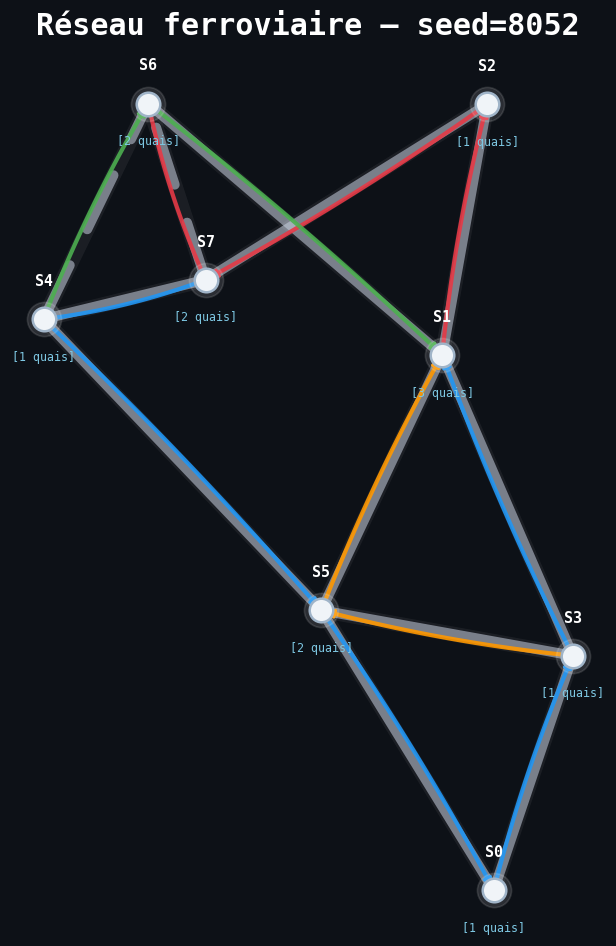

In [31]:
fig_map = plot_railway_network(
    net,
    title=f"Réseau ferroviaire — seed={SEED}",
    figsize=(12, 8),
    show=False,
)
plt.show()

---
## 4 · Résolution du problème de timetabling (PESP / CP-SAT)

Le solver cherche des temps d'arrivée et de départ (mod T) satisfaisant :
- Les temps de trajet sur chaque segment
- Les temps de stationnement en gare (dwell)
- Les contraintes de correspondance entre lignes
- L'absence de conflit sur les voies uniques (NoOverlap)
- La capacité des quais (Cumulative)

In [32]:
solution = solve(net, time_limit_seconds=SOLVER_TIME_LIMIT)

if solution is None:
    print("Pas de solution trouvée. Essayez un autre seed ou augmentez T.")
else:
    print("Solution trouvée !\n")
    print(f"{'Ligne':<6} {'Station':<10} {'Arrivée':>8} {'Départ':>8}")
    print("-" * 36)
    for line, route in net.lines.items():
        for station in route:
            arr = solution[(line, station, "arr")]
            dep = solution[(line, station, "dep")]
            print(f"{line:<6} {station:<10} {arr:>8} {dep:>8}")
        print()


Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 30 log_search_progress: true
Setting number of workers to 6

Initial satisfaction model '': (model_fingerprint: 0xb7fafb345ba72c2e)
#Variables: 106 (43 primary variables)
  - 13 Booleans in [0,1]
  - 16 in [0,6]
  - 48 in [0,59]
  - 16 in [0,65]
  - 1 in [1,8]
  - 2 in [5,9]
  - 2 in [6,7]
  - 2 in [6,9]
  - 2 in [7,8]
  - 4 in [7,9]
#kCumulative: 6 (#intervals: 14, #variable_sizes: 14)
#kInterval: 16
#kLinear2: 60
#kLinear3: 16
#kLinearN: 13 (#terms: 52)

Starting presolve at 0.00s
  3.81e-05s  0.00e+00d  [DetectDominanceRelations] 
  2.64e-03s  0.00e+00d  [PresolveToFixPoint] #num_loops=2 #num_dual_strengthening=1 
  3.20e-06s  0.00e+00d  [ExtractEncodingFromLinear] 
  1.01e-05s  0.00e+00d  [DetectDuplicateColumns] 
  2.18e-05s  0.00e+00d  [DetectDuplicateConstraints] #duplicates=24 
[Symmetry] Graph for symmetry has 203 nodes and 165 arcs.
[Symmetry] Symmetry computation done. time: 3.8087e-05 dtime: 3.574e-05
  1.6

---
## 5 · Rescheduling de perturbation

Une perturbation est introduite sur un événement de départ, et le solveur de
recovery réoptimise le timetable en minimisant les retards supplémentaires.

In [33]:
if solution is not None:
    delayed_line = list(net.lines.keys())[0]
    delayed_station = net.lines[delayed_line][1]
    perturbation = {(delayed_line, delayed_station, "dep"): 5}
    recovery = solve_recovery(
        net,
        solution,
        perturbation,
        time_limit_seconds=SOLVER_TIME_LIMIT,
    )
    print("test")

    if recovery is None:
        print("❌ Pas de solution de recovery trouvée pour le retard demandé.")
    else:
        print(f"✅ Retard de +{perturbation[(delayed_line, delayed_station, 'dep')]} min sur {delayed_line} à {delayed_station}")
        print(f"{'Ligne':<6} {'Station':<10} {'Base arr':>8} {'Base dep':>8} {'New arr':>8} {'New dep':>8}")
        print("-" * 56)
        for line, route in net.lines.items():
            for station in route:
                print(
                    f"{line:<6} {station:<10} "
                    f"{solution[(line, station, 'arr')]:>8} {solution[(line, station, 'dep')]:>8} "
                    f"{recovery[(line, station, 'arr')]:>8} {recovery[(line, station, 'dep')]:>8}"
                )
            print()
else:
    print("Pas de perturbation possible sans solution initiale.")


Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 30 log_search_progress: true
Setting number of workers to 6

Initial optimization model '': (model_fingerprint: 0xf872be2a6eaf38dd)
#Variables: 108 (#ints: 1 in objective) (44 primary variables)
  - 14 Booleans in [0,1]
  - 16 in [0,6]
  - 48 in [0,59]
  - 16 in [0,65]
  - 1 in [1,8]
  - 2 in [5,9]
  - 1 in [5,59]
  - 2 in [6,7]
  - 2 in [6,9]
  - 2 in [7,8]
  - 4 in [7,9]
#kCumulative: 6 (#intervals: 14, #variable_sizes: 14)
#kInterval: 16
#kLinear2: 60
#kLinear3: 17
#kLinearN: 13 (#terms: 52)

Starting presolve at 0.00s
  3.51e-05s  0.00e+00d  [DetectDominanceRelations] 
  7.22e-04s  0.00e+00d  [PresolveToFixPoint] #num_loops=4 #num_dual_strengthening=1 
  2.70e-06s  0.00e+00d  [ExtractEncodingFromLinear] 
  8.30e-06s  0.00e+00d  [DetectDuplicateColumns] 
  1.37e-04s  0.00e+00d  [DetectDuplicateConstraints] #duplicates=24 
[Symmetry] Graph for symmetry has 205 nodes and 165 arcs.
[Symmetry] Symmetry computation done.

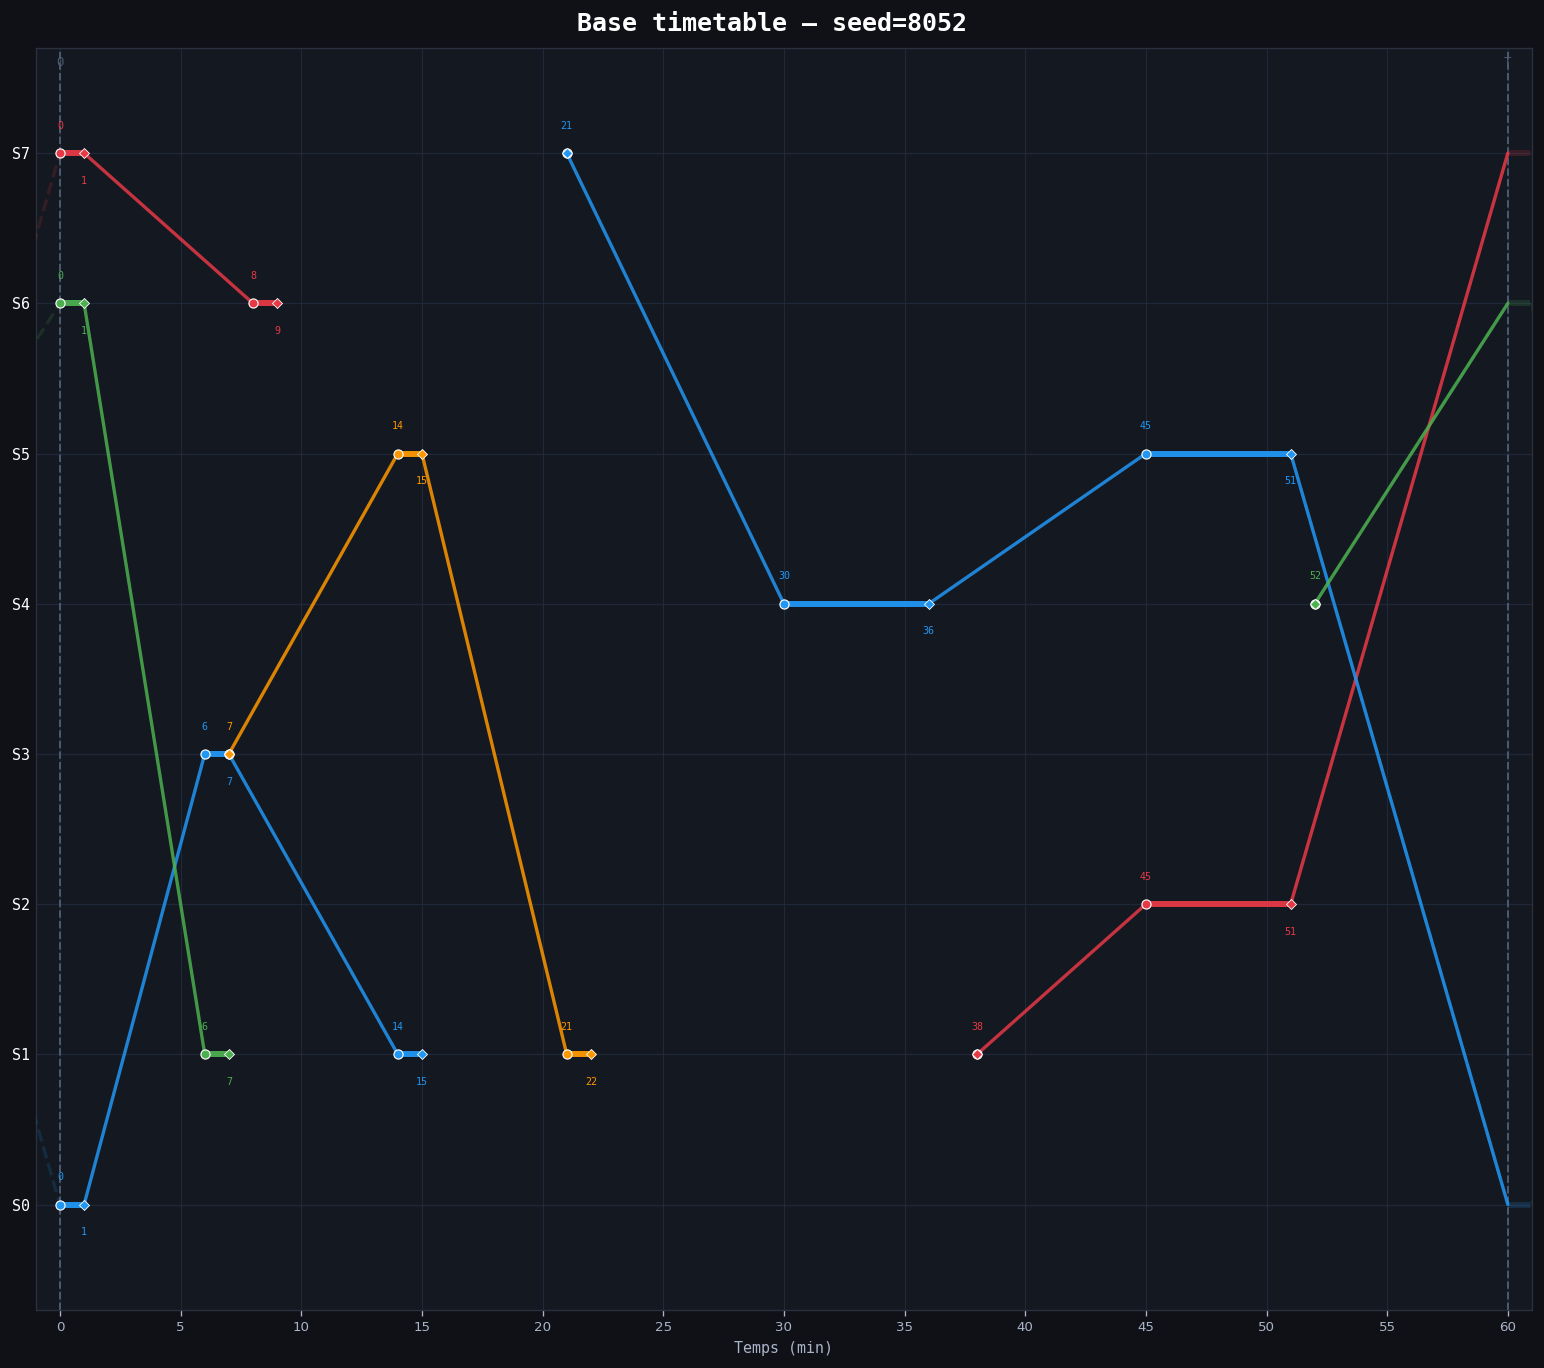

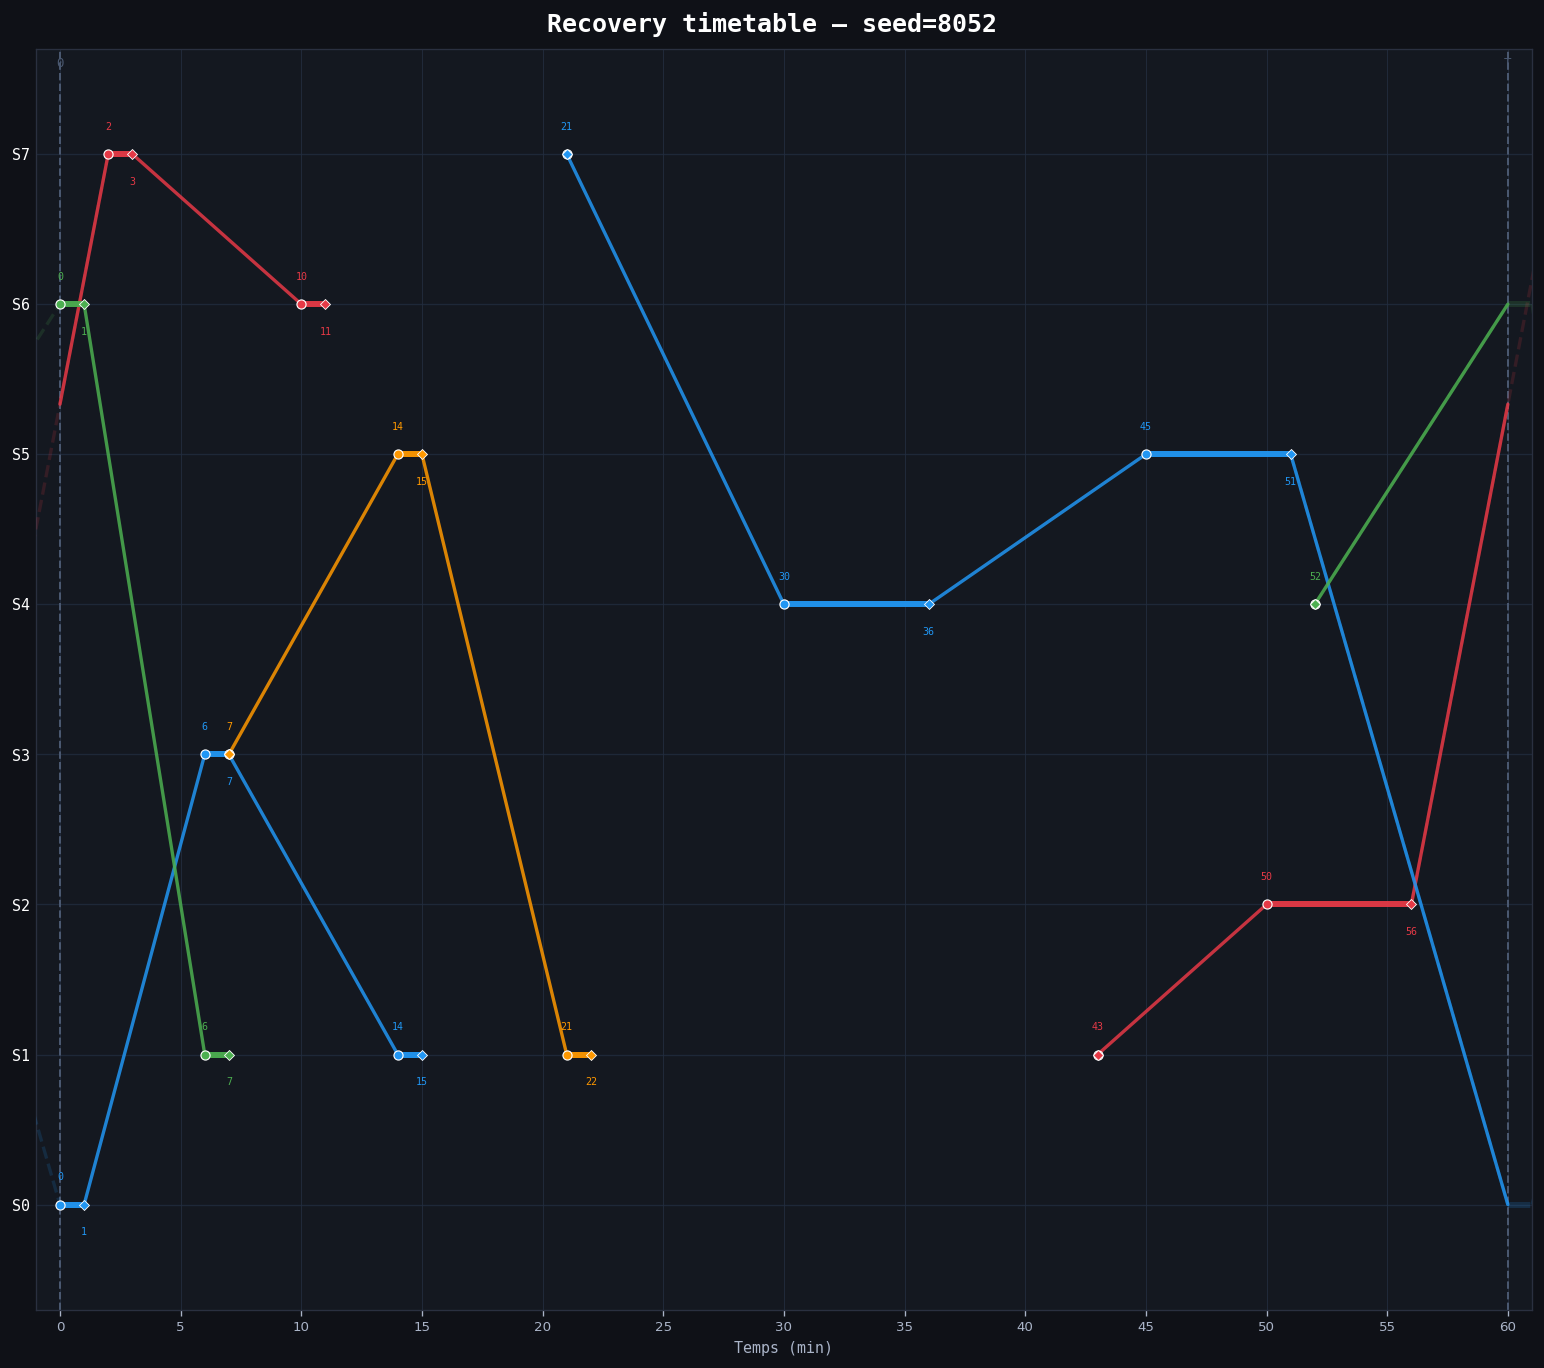

In [38]:
# Visualisation : diagrammes espace-temps avant / après rescheduling
# Affiche deux figures séparées (base, recovery) pour comparaison visuelle.
if 'solution' in globals() and solution is not None:
    try:
        if 'recovery' in globals() and recovery is not None:
            # Base timetable
            _ = plot_spacetime(net, solution, title=f"Base timetable — seed={SEED}", show=False)
            # Recovery timetable
            _ = plot_spacetime(net, recovery, title=f"Recovery timetable — seed={SEED}", show=False)
            plt.show()
        else:
            print('Aucune solution de recovery disponible pour affichage.')
    except Exception as e:
        print('Erreur lors du tracé des diagrammes espace-temps:', e)
else:
    print('Aucune solution initiale disponible pour affichage.')

---
## 6 · Diagramme espace-temps

- **Axe X** : temps (0 → T)
- **Axe Y** : stations ordonnées globalement
- **Diagonal** : trajet entre deux stations
- **Horizontal** : stationnement (dwell)
- **Tiretés** : répétition périodique (±T)

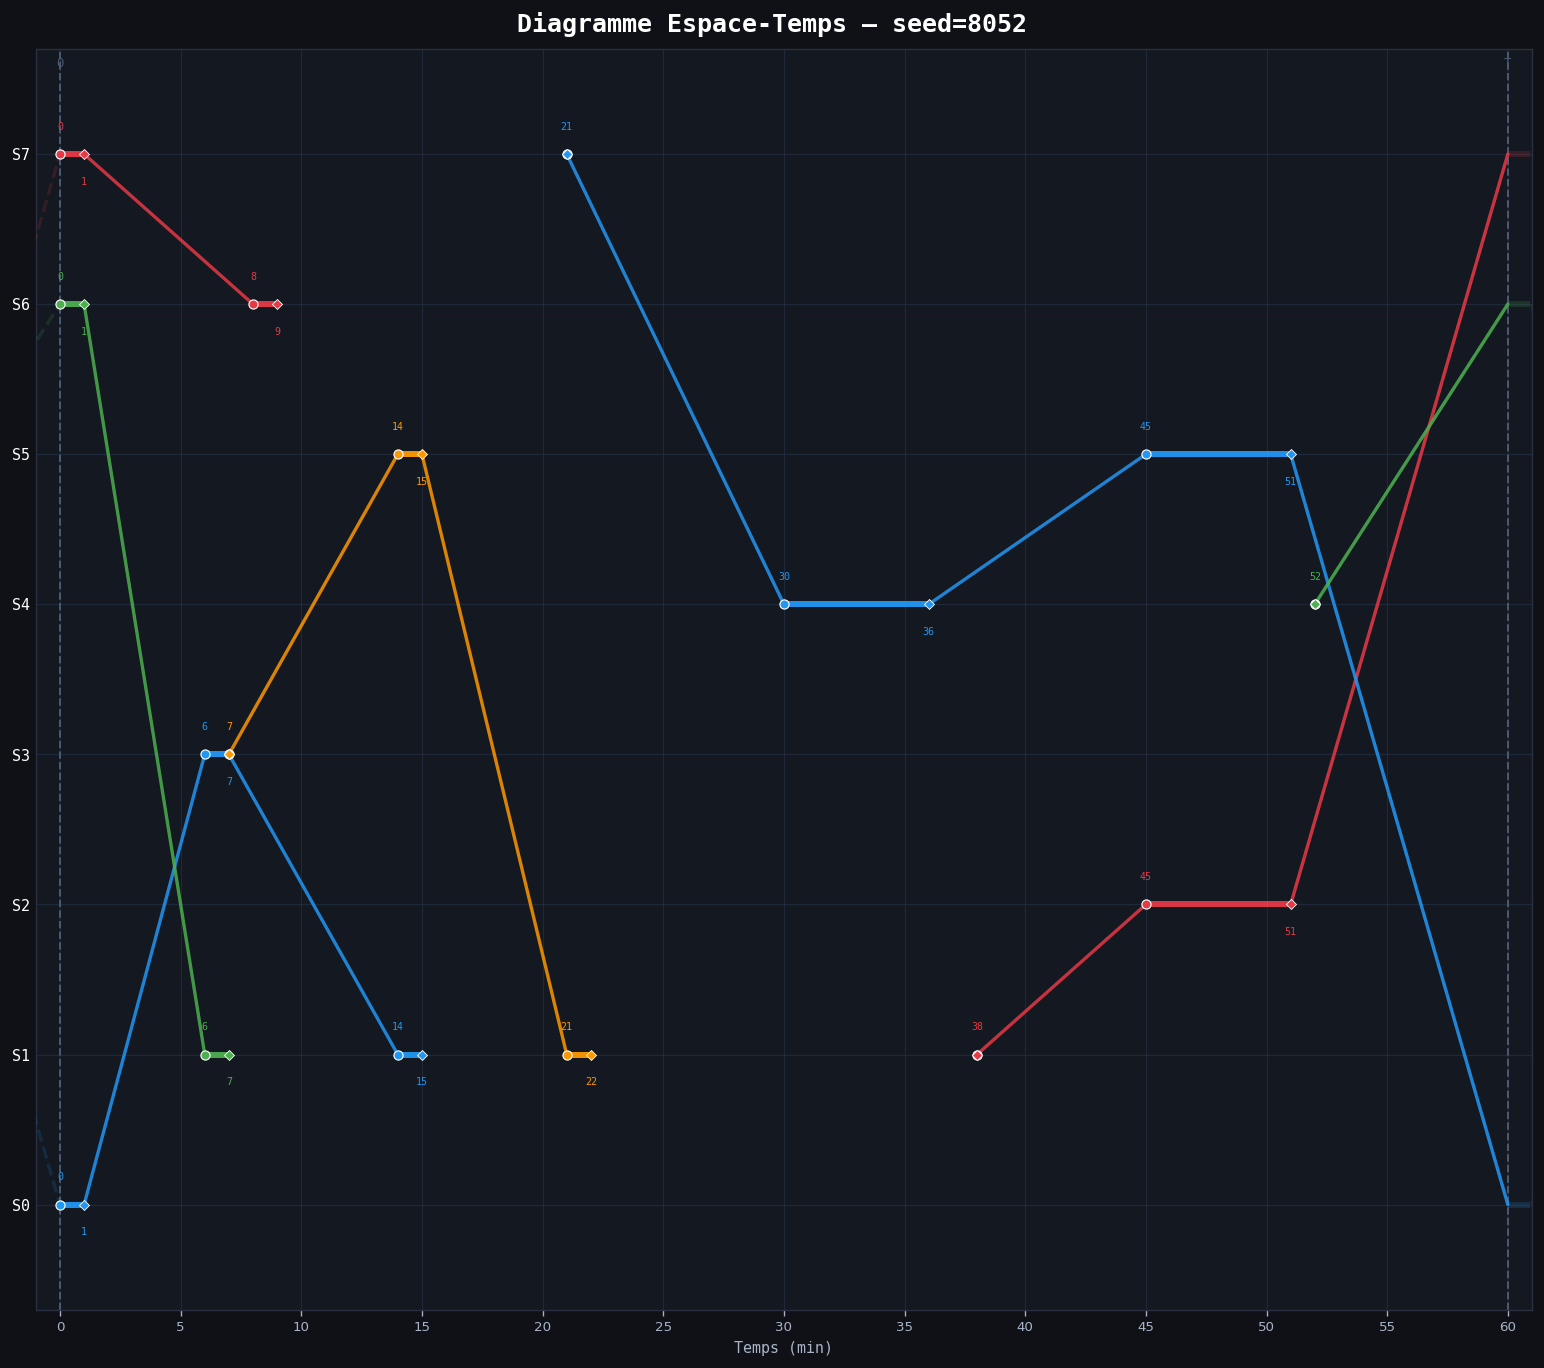

In [35]:
if solution is not None:
    fig_st = plot_spacetime(
        net,
        solution,
        title=f"Diagramme Espace-Temps — seed={SEED}",
        figsize=(13, max(5, 1.2 * len(net.stations) + 2)),
        show=False,
    )
    plt.show()
else:
    print("Pas de diagramme à afficher (aucune solution).")

---

# 7. Tests de scalabilité

On mesure le temps de résolution pour plusieurs tailles de réseau afin de
comparer la performance du modèle sur des instances plus grandes.

In [ ]:
from time import perf_counter

benchmarks = [
    (10, 3),
    (15, 4),
    (20, 5),
    (30, 7),
    (40, 9),
    (303, 16),
]

print(f"{'Stations':>8} | {'Lignes':>6} | {'Temps (s)':>8} | {'Solution':>8}")
print('-' * 38)
for n_stations, n_lines in benchmarks:
    net_bench = generate_railway_network(
        n_stations=n_stations,
        n_lines=n_lines,
        T=T,
        seed=SEED,
    )
    start = perf_counter()
    sol_bench = solve(net_bench, time_limit_seconds=30.0)
    elapsed = perf_counter() - start
    status = 'OK' if sol_bench is not None else 'FAIL'
    print(f"{n_stations:8d} | {n_lines:6d} | {elapsed:8.2f} | {status:>8}")


Starting CP-SAT solver v9.15.6755
Parameters: max_time_in_seconds: 10 log_search_progress: true
Setting number of workers to 6

Initial satisfaction model '': (model_fingerprint: 0x24c428ddaf6794e8)
#Variables: 80 (33 primary variables)
  - 10 Booleans in [0,1]
  - 12 in [0,6]
  - 36 in [0,59]
  - 12 in [0,65]
  - 1 in [2,7]
  - 1 in [4,5]
  - 2 in [4,7]
  - 4 in [5,6]
  - 2 in [5,7]
#kCumulative: 3 (#intervals: 7, #variable_sizes: 7)
#kInterval: 12
#kLinear2: 45
#kLinear3: 12
#kLinearN: 10 (#terms: 40)

Starting presolve at 0.00s
  1.00e-04s  0.00e+00d  [DetectDominanceRelations] 
  1.72e-03s  0.00e+00d  [PresolveToFixPoint] #num_loops=2 #num_dual_strengthening=1 
  3.19e-06s  0.00e+00d  [ExtractEncodingFromLinear] 
  1.17e-05s  0.00e+00d  [DetectDuplicateColumns] 
  1.77e-05s  0.00e+00d  [DetectDuplicateConstraints] #duplicates=18 
[Symmetry] Graph for symmetry has 141 nodes and 103 arcs.
[Symmetry] Symmetry computation done. time: 6.9861e-05 dtime: 2.366e-05
  4.77e-05s  0.00e+00d 

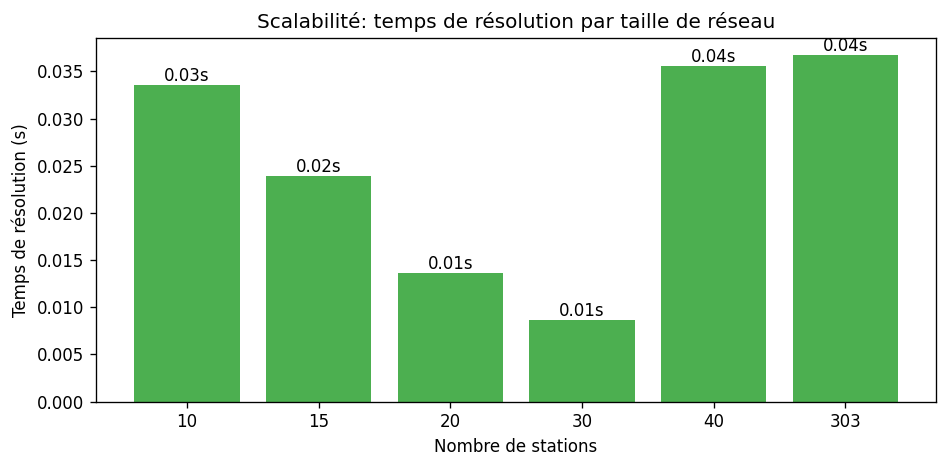

In [37]:
# Scalability plot: bar chart of solution times
try:
    from matplotlib import pyplot as _plt
    if 'benchmarks' in globals():
        sizes = []
        times = []
        statuses = []
        for n_stations, n_lines in benchmarks:
            sizes.append(n_stations)
            # If sol_bench exists for this benchmark run, try to read elapsed
            key = (n_stations, n_lines)
            # We store timing results in a dict `bench_results` if present
            if 'bench_results' in globals() and key in bench_results:
                t, ok = bench_results[key]
            else:
                # Fallback: re-run quickly with small time limit (best-effort)
                net_bench = generate_railway_network(n_stations, n_lines, T, seed=SEED)
                _start = perf_counter()
                sol_b = solve(net_bench, time_limit_seconds=10.0)
                t = perf_counter() - _start
                ok = sol_b is not None
            times.append(t)
            statuses.append(ok)

        fig = _plt.figure(figsize=(8,4))
        bars = _plt.bar([str(s) for s in sizes], times, color=['#4CAF50' if ok else '#E53946' for ok in statuses])
        _plt.xlabel('Nombre de stations')
        _plt.ylabel('Temps de résolution (s)')
        _plt.title('Scalabilité: temps de résolution par taille de réseau')
        for rect, t in zip(bars, times):
            _plt.text(rect.get_x() + rect.get_width()/2, rect.get_height(), f"{t:.2f}s", ha='center', va='bottom')
        _plt.tight_layout()
        _plt.show()
    else:
        print('Pas de données de benchmark trouvées dans le notebook.')
except Exception as e:
    print('Erreur lors du tracé de scalabilité:', e)